In [2]:
import os
import pickle
import pandas as pd
import sklearn.metrics
import matplotlib.pyplot as plt
import re

      positions  immuno_bin  immuno_bin_ba  immuno_mix  immuno_mix_ba  \
0    1, 2, 3, 4    0.475248       0.500000    0.634146       0.655738   
1    1, 2, 3, 5    0.416667       0.468085    0.640625       0.611570   
2    1, 2, 3, 6    0.431818       0.415584    0.656000       0.656250   
3    1, 2, 3, 7    0.626263       0.585859    0.676923       0.701754   
4    1, 2, 3, 8    0.484848       0.505051    0.606557       0.693548   
..          ...         ...            ...         ...            ...   
121  5, 6, 7, 8    0.576923       0.456522    0.635514       0.446809   
122  5, 6, 7, 9    0.623853       0.600000    0.724138       0.718447   
123  5, 6, 8, 9    0.580000       0.537634    0.713043       0.728972   
124  5, 7, 8, 9    0.530612       0.600000    0.704762       0.723077   
125  6, 7, 8, 9    0.559140       0.488372    0.706897       0.763636   

     mhc_binding  
0       0.727273  
1       0.730159  
2       0.733333  
3       0.701754  
4       0.666667  
..       

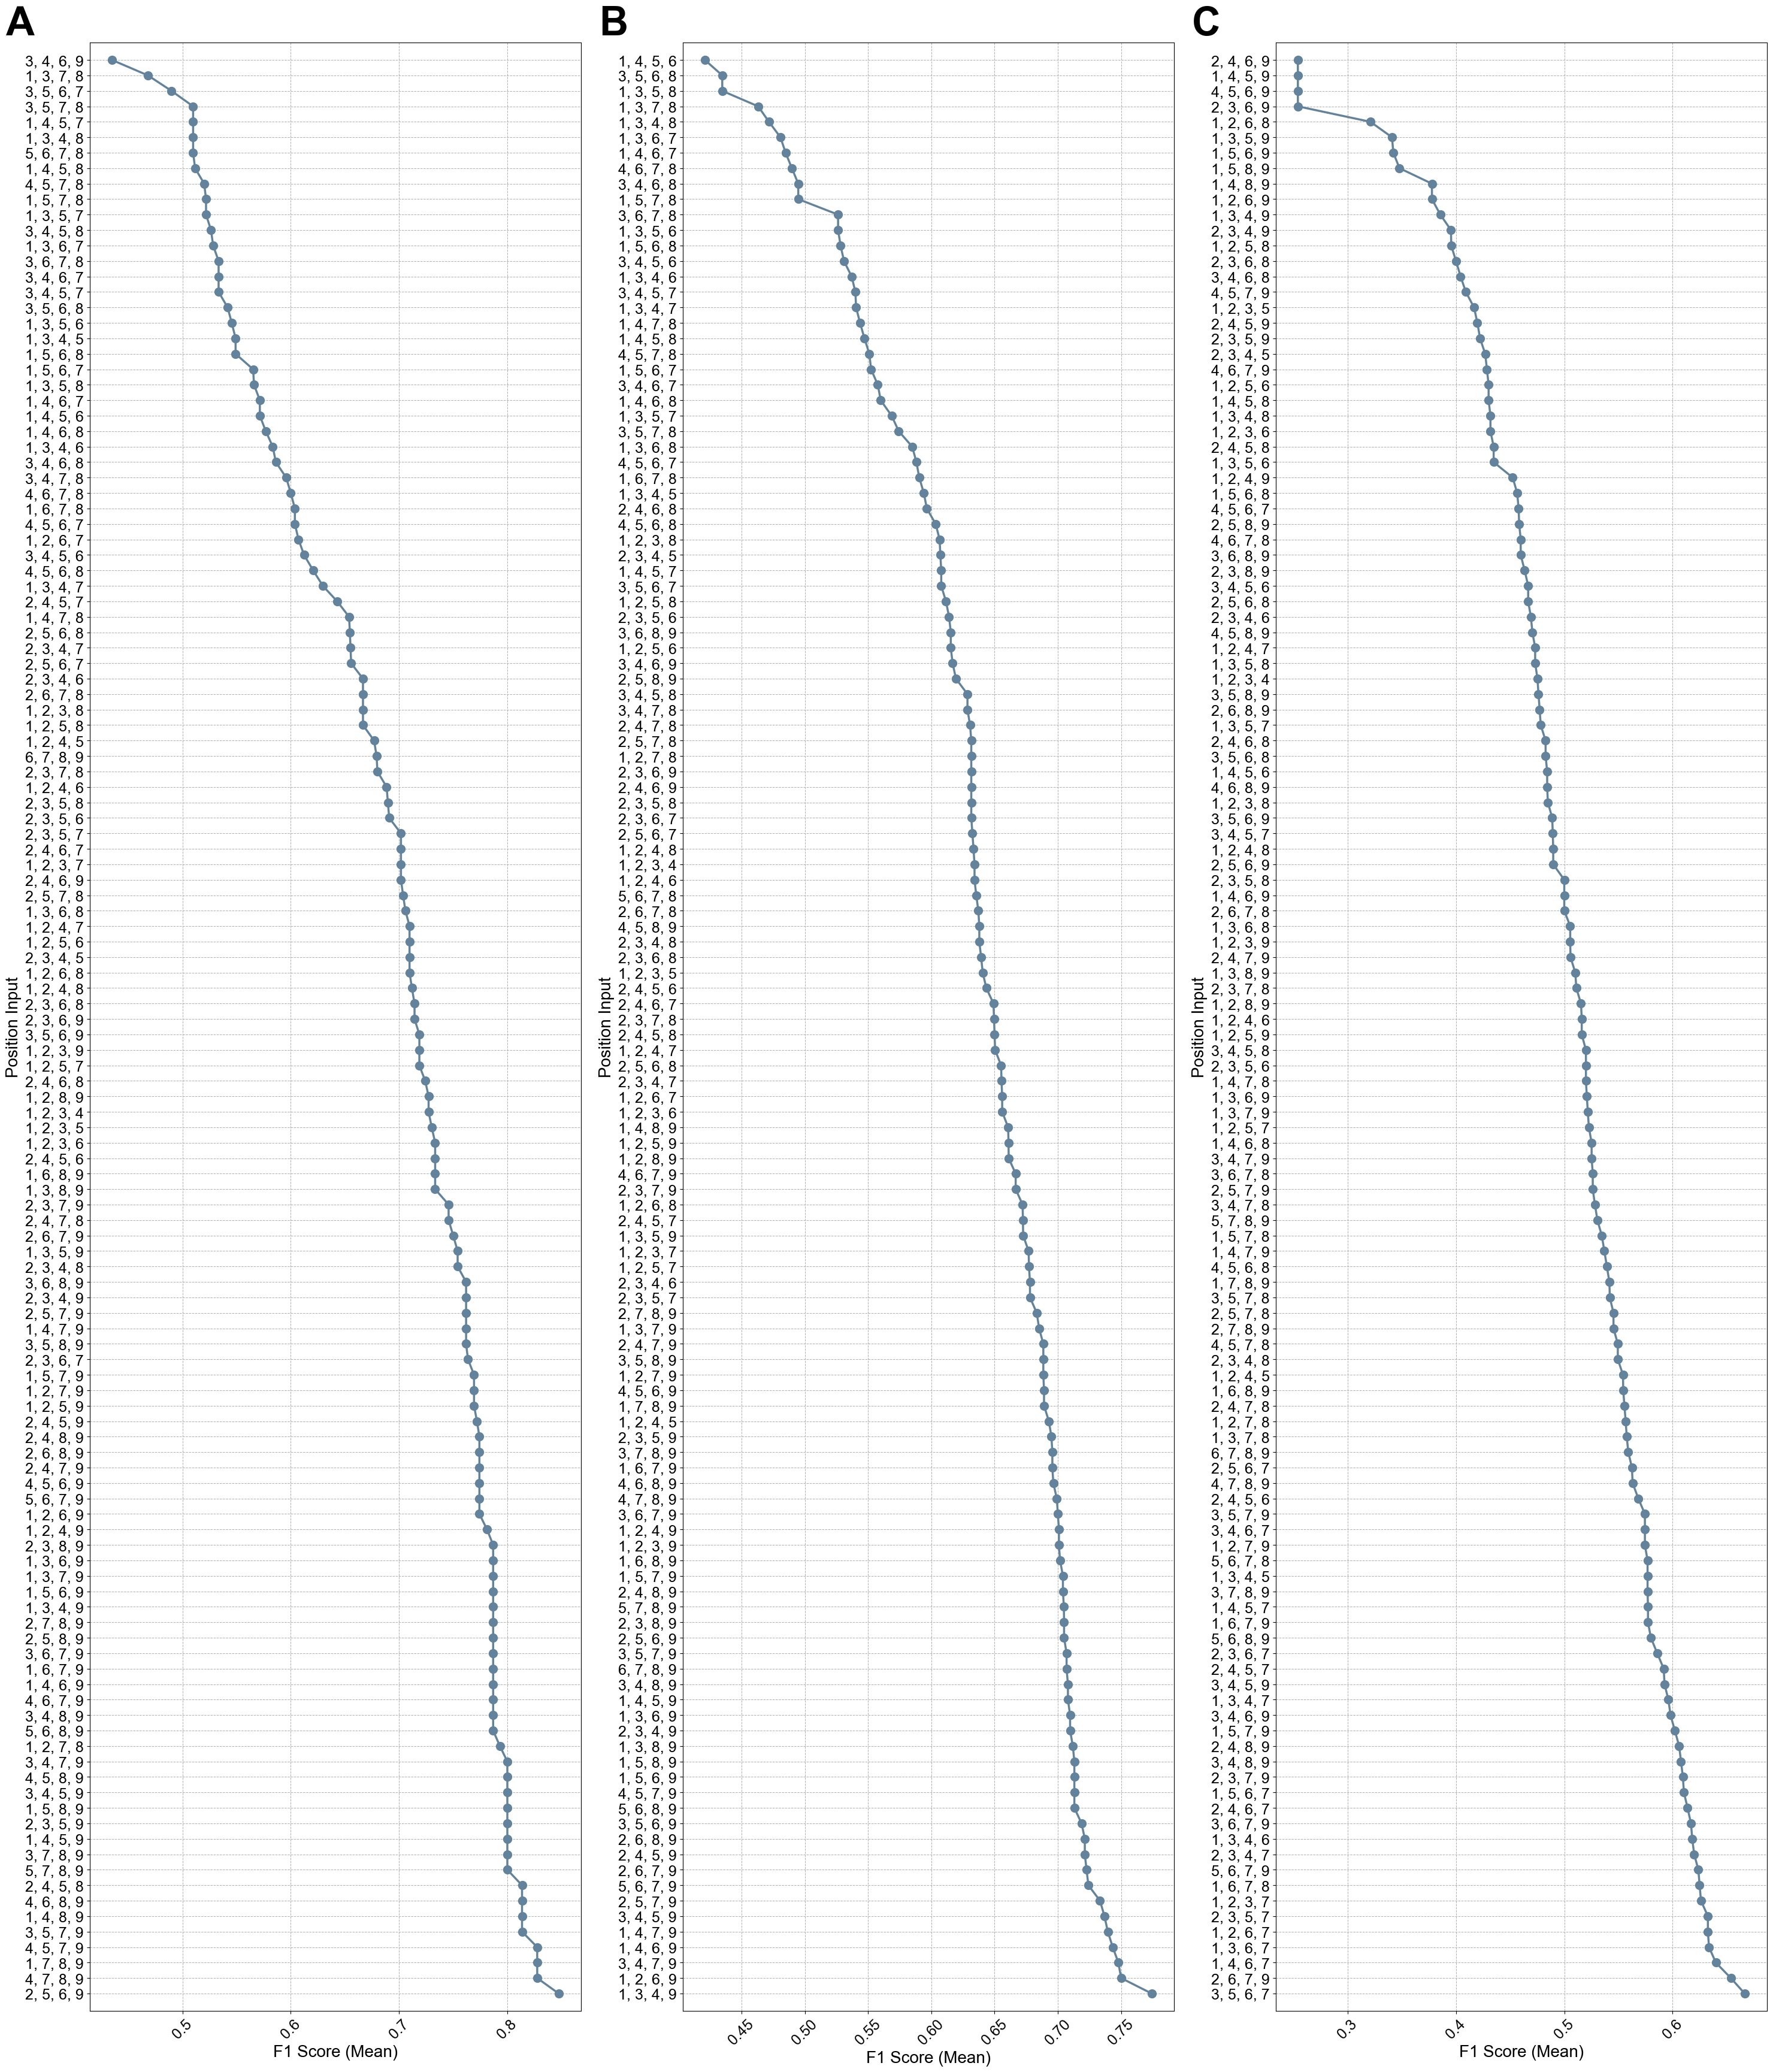

In [4]:
# Experiment result directories (excluding 'ba' variants)
dirs = {
    'mhc_binding': '../../qcnn/experiments/exp3_binding_1234',
    'immuno_mix':  '../../qcnn/experiments/exp5_immuno_1234_mix',
    'immuno_mix_ba': '../../qcnn/experiments/exp6_immuno_1234ba_mix',
    'immuno_bin':  '../../qcnn/experiments/exp7_immuno_1234_bin',
    'immuno_bin_ba': '../../qcnn/experiments/exp8_immuno_1234ba_bin'
}

# Regex patterns per experiment key
regex_patterns = {
    'mhc_binding': r'_binding.pkl$',
    'immuno_mix':  r'_immuno.pkl$',
    'immuno_mix_ba': r'ba_immuno.pkl$',
    'immuno_bin':  r'_immuno.pkl$',
    'immuno_bin_ba': r'ba_immuno.pkl$',
}

# Plot titles per experiment key
plot_titles = [
    'mhc_binding',
    'immuno_mix',
    'immuno_bin',
]

# ── Load all results into per-experiment DataFrames ──────────────────────
dfs = {}

for key, dir_output in dirs.items():
    files_experiments = [x for x in os.listdir(dir_output) if 'pkl' in x]
    pattern = regex_patterns[key]
    scores = {}

    for file in files_experiments:
        with open(f'{dir_output}/{file}', 'rb') as f:
            data = pickle.load(f)

        true_labels = [0 if x == -1 else x for x in data['test_labels']]
        pred_labels = [0 if int(x) == -1 else int(x) for x in data['test_pred']]
        scores[file] = sklearn.metrics.f1_score(true_labels, pred_labels)

    df = pd.DataFrame.from_dict(scores, orient='index', columns=['f1_score'])
    df.index.name = 'filename'
    df = df.reset_index()

    # Strip suffix to get raw position string, then convert to 1-indexed labels
    df['positions'] = [re.sub(pattern, '', i) for i in df['filename']]
    df['positions'] = [', '.join(str(int(j) + 1) for j in i) for i in df['positions']]

    # Average F1 across replicates per position
    df = df.groupby('positions', as_index=False)['f1_score'].mean()
    df = df.sort_values(by='f1_score', ascending=False)
    df['experiment'] = key

    dfs[key] = df


# ── Combined DataFrame ───────────────────────────────────────────────────
df_all = pd.concat(dfs.values(), ignore_index=True)
df_all = df_all.pivot(index='positions', columns='experiment', values='f1_score')
df_all.columns.name = None
df_all = df_all.reset_index()
print(df_all)



# ── Plotting ─────────────────────────────────────────────────────────

# subset dfs to only those in 'plot_titles'
dfs = {k: v for k, v in dfs.items() if k in plot_titles}

COLOR = (98/255, 131/255, 155/255)
plt.rcParams.update({
    'font.family':    'Arial',
    'font.size':       20,
    'axes.titlesize':  18,
    'axes.labelsize':  18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
})

def plot_single(ax, df):
    ax.plot(
        df['f1_score'], df['positions'],
        marker='o', linestyle='-',
        color=COLOR, markersize=10, linewidth=2.5,
    )
    ax.set_xlabel("F1 Score (Mean)", fontsize=20)
    ax.set_ylabel("Position Input", fontsize=20)
    ax.margins(y=0.009)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', linewidth=0.7)

fig, axes = plt.subplots(1, 3, figsize=(30, 35))
panel_labels = ['A', 'B', 'C']

for ax, (key, df), label in zip(axes, dfs.items(), panel_labels):
    plot_single(ax, df)
    # Place label above and to the left of the axes
    ax.text(
        -0.17, 1, label,
        transform=ax.transAxes,
        fontsize=48, fontweight='bold',
        va='bottom', ha='left',
    )

plt.tight_layout()
plt.savefig(f'extended_pos_plots.svg', dpi=500, bbox_inches='tight')
plt.show()